## 接phase2进行动量改动，下部分代码算是很完整了有vol控制的

In [8]:

#这两行代码是告诉ipynb，只要我运行cell，就去检查旁边.py文件看有没有被修改，如果修改了就重新读入

#读取之前用的函数
from functions import metrics_from_bt
#读取本地数据的代码
import pandas as pd
import numpy as np

# 1. 一步到位：读取 CSV，同时告诉 Pandas 把第 0 列当成索引，并尝试解析为时间格式
clean_data_path = "data/BTCUSDT_1h_6y_cleaned.csv"
df = pd.read_csv(clean_data_path, index_col=0, parse_dates=True)

# 2. (可选) 终极保险：强制确认一下索引是 UTC 时区格式
# 有时候 CSV 存取会丢失时区信息，加上这句可以保证万无一失
df.index = pd.to_datetime(df.index, utc=True)

# 检查结果
print("数据前 3 行：\n", df.head(3))
print("\n当前的索引类型：\n", type(df.index))

df6y=df
df_all = df6y.copy()

# 因为 open_time 已经是 index
df_all = df_all.sort_index()   # ✅ 改这里

n = len(df_all)
split = int(n * 0.7)

train_df = df_all.iloc[:split].copy()
test_df  = df_all.iloc[split:].copy()
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

数据前 3 行：
                               open     high      low    close       volume  \
2020-03-01 00:00:00+00:00  8523.61  8613.57  8511.11  8547.25  1952.740520   
2020-03-01 01:00:00+00:00  8546.65  8649.00  8514.06  8639.28  1901.273287   
2020-03-01 02:00:00+00:00  8640.23  8675.00  8617.73  8630.86  1271.182357   

                                                 close_time  \
2020-03-01 00:00:00+00:00  2020-03-01 00:59:59.999000+00:00   
2020-03-01 01:00:00+00:00  2020-03-01 01:59:59.999000+00:00   
2020-03-01 02:00:00+00:00  2020-03-01 02:59:59.999000+00:00   

                           quote_asset_volume  number_of_trades  \
2020-03-01 00:00:00+00:00        1.673789e+07           22876.0   
2020-03-01 01:00:00+00:00        1.630347e+07           24731.0   
2020-03-01 02:00:00+00:00        1.098729e+07           16257.0   

                           taker_buy_base_asset_volume  \
2020-03-01 00:00:00+00:00                   899.851144   
2020-03-01 01:00:00+00:00              

In [11]:
ANNUAL=24*365

def ema_trend_voltarget_backtest(
    df,
    ema_fast=24,
    ema_slow=168,
    vol_lookback=72,
    vol_target_annual=0.20,
    fee_rate=0.0004,
    w_max=1.0
):

    data = df.copy()

    if "return" not in data.columns:
        data["return"] = data["close"].pct_change()

    # -------------------
    # 1 EMA计算
    # -------------------
        #重要公式 相对于rolling，ewm是指数衰减的，权重嘛
    ema_fast_series = data["close"].ewm(span=ema_fast).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow).mean()

    # trend signal
    trend = ema_fast_series / ema_slow_series - 1

    # -------------------
    # 2 volatility
    # -------------------

    vol = data["return"].rolling(vol_lookback).std().replace(0, np.nan)

    # risk adjusted signal
    signal = trend / vol

    # -------------------
    # 3 continuous position
    # -------------------

    direction = np.tanh(signal).fillna(0)

    vol_target_hourly = vol_target_annual / np.sqrt(ANNUAL)

    size = (vol_target_hourly / vol).clip(upper=w_max).fillna(0)

    target_pos = direction * size

    pos = target_pos.shift(1).fillna(0)

    # -------------------
    # 4 cost
    # -------------------

    turnover = pos.diff().abs().fillna(0)

    cost = fee_rate * turnover

    # -------------------
    # 5 strategy return
    # -------------------

    strat_ret = pos * data["return"] - cost

    equity = (1 + strat_ret).cumprod()

    peak = equity.cummax()

    drawdown = equity / peak - 1

    return pd.DataFrame({
        "pos": pos,
        "equity": equity,
        "drawdown": drawdown,
        "strategy_ret": strat_ret
    })

bt_train_ema = ema_trend_voltarget_backtest(train_df)
bt_test_ema = ema_trend_voltarget_backtest(test_df)




train_metrics = metrics_from_bt(bt_train_ema)
test_metrics  = metrics_from_bt(bt_test_ema)

print("=== EMA Trend Strategy ===")
print("TRAIN:", train_metrics)
print("TEST :", test_metrics)


=== EMA Trend Strategy ===
TRAIN: (0.5448248154403731, -0.2952898307096071, 0.47302812765545776)
TEST : (0.2917050977446649, -0.18679412976375165, 0.07198007768873693)


这是将趋势指标使用了EMA（）/EMA() - 1，之后得到的结果 算是一个趋势滤波器。得到的结果相对于之前的量化策略模型已经相较之下更好了，我们的test_sharpe至少是个正值了。\
但是就像机器学习一样，我们现在是给函数喂参数，这个EMA的值应当进行一个扫描，来找最佳的动量指标。而且要去看这个策略是不是过拟合，它健康不健康。

**Parameter Surface（参数面）。**

如果策略健康，你会看到，一片平台。而不是：一个尖峰

In [5]:
results = []

fast_list = [12, 24, 48]
slow_list = [72, 168, 336]

for fast in fast_list:
    for slow in slow_list:

        bt_test = ema_trend_voltarget_backtest(
            test,
            ema_fast=fast,
            ema_slow=slow
        )

        sharpe, maxdd, ret = metrics_from_bt(bt_test)

        results.append({
            "fast": fast,
            "slow": slow,
            "sharpe": sharpe,
            "maxdd": maxdd,
            "ret": ret
        })

scan_df = pd.DataFrame(results)

print(scan_df)


   fast  slow    sharpe     maxdd       ret
0    12    72  0.206067 -0.268761  0.038834
1    12   168  0.280475 -0.199611  0.067916
2    12   336  0.689843 -0.208973  0.246850
3    24    72  0.475453 -0.206398  0.134644
4    24   168  0.291705 -0.186794  0.071980
5    24   336  0.635296 -0.203818  0.221496
6    48    72  0.512023 -0.131520  0.120167
7    48   168  0.267700 -0.177770  0.061945
8    48   336  0.863191 -0.143422  0.328528


结果解读：

1.slow EMA 越大 Sharpe 越高  说明：long-term trend > short-term trend

2.最大 Sharpe：

EMA(48 , 336)
Sharpe = 0.84

但我们不能直接说：

最佳参数 = 48 / 336

因为：

sample noise

真实量化研究通常会做：

parameter clustering

例如：

slow ≈ 300–400
fast ≈ 24–72

**结果还不错，48/336参数，使用EMA趋势策略，因为测试集是1.8年，年化收益率能达到17%，回撤-14%。**

# Phase 3 — Strategy Research
## Task 3.2 — Multi-horizon Momentum
### Step 1 — Build multiple EMA signals
目标：
1. 定义多个 EMA 参数对
2. 为每个参数对计算 trend signal
3. 把所有子信号整理成一个 DataFrame

In [12]:
import numpy as np
import pandas as pd

# 1) 定义 EMA 函数
def ema(series, span): #span是ema的窗口参数，ewm是指数加权
    return series.ewm(span=span, adjust=False).mean()
#adjust=False 按更适合实时递推的方式计算 EMA。

# 2) 定义我们要研究的参数组合
pairs = [
    (12, 72), (12, 168), (12, 336),
    (24, 72), (24, 168), (24, 336),
    (48, 72), (48, 168), (48, 336),
]

# 3) 准备收益率和波动率
ret = df["close"].pct_change() #df close是一个series时间序列，signal_df是一个dataframe
vol = ret.ewm(span=24 * 7, adjust=False).std()
#用大约七天的指数加权窗口估计波动率
# 4) 为每个参数对计算 signal
signal_dict = {}

for fast, slow in pairs:
    ema_fast = ema(df["close"], fast)
    ema_slow = ema(df["close"], slow)

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol

    col_name = f"sig_{fast}_{slow}" #给这一列信号起一个名字
    signal_dict[col_name] = signal

# 5) 合并成一个 DataFrame
signal_df = pd.DataFrame(signal_dict, index=df.index)

# 6) 看一下结果
signal_df.tail()

,sig_12_72,sig_12_168,sig_12_336,sig_24_72,sig_24_168,sig_24_336,sig_48_72,sig_48_168,sig_48_336
2026-02-28 20:00:00+00:00,-1.105660,-2.035958,-4.173219,-1.290711,-2.219829,-4.354375,-0.494356,-1.428557,-3.574782
2026-02-28 21:00:00+00:00,-0.715762,-1.614176,-3.749505,-1.099140,-1.995206,-4.124958,-0.452318,-1.352345,-3.491508
2026-02-28 22:00:00+00:00,-0.281153,-1.133403,-3.257633,-0.877298,-1.726102,-3.841745,-0.399945,-1.251508,-3.374027
2026-02-28 23:00:00+00:00,0.041830,-0.772243,-2.892799,-0.694274,-1.504315,-3.614366,-0.355721,-1.167616,-3.282499
2026-03-01 00:00:00+00:00,0.258009,-0.524198,-2.640787,-0.549114,-1.327098,-3.432263,-0.319155,-1.098342,-3.206762


我们之前扫描出来了一对参数也就是 fast48，slow336,现在不止算一组参数，而是把9个参数组放在一起，生成一个Dataframe，这样我们接下来才能研究：\
哪些 signal 更强

它们之间像不像

怎么组合成 multi-horizon signal

从单信号，升级到信号池。


**现在有点迷了，信号，动量，仓位的概念**

在量化里，和一个策略通常是一个链条：
价格                
 ↓
Feature / Indicator 指标/特征
 ↓
Signal              交易信号
 ↓
Position mapping    仓位函数
 ↓
Position            仓位
 ↓
PnL                 收益

我们现在这套EMA策略：

step1 价格：close 收盘价，市场原始数据

step2 Feature（指标）我们用的是EMA trend

    trend = EMA_fast / EMA_slow - 1，它回答当前短期趋势相对长期趋势有多强？

step3  Signal（信号）signal = trend / vol

step4 Position Mapping（仓位函数）：

我们用的是pos = tanh(signal=trend / vol)**单位波动下的趋势强度**，它把signal映射到【-1，1】，波动率高的仓位的低一些，波动率低的仓位高一些\
step5 Postion（最终仓位）\
这是再加上vol targeting的\
final_pos = pos * leverage

step6 Pnl最后计算收益：strategy_return = final_pos.shift(1) * market_return

这里动量或者叫趋势指标是：trend = EMA_fast / EMA_slow - 1

交易信号是：signal = trend / vol

目标仓位：pos = tanh(signal)


再一个比较大的问题是，我们在上面是进行了尝试性探索使用的是full sample。一直到我们phase3之前都是用的全数据集，我们已经验证了这个ema的alpha还是有点潜力的，接下来就要进入正式研究过程，前面都是探索。

首先是简单对不同时间尺度的信号进行普通加权生成combo信号


In [ ]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 3 — Equal-weight combo signal
# ============================================

# 1) multi-horizon signal (equal weight)
combo_signal = signal_df.mean(axis=1) #在dataframe中，axis=0是按照列方向计算，=1是按照行方向计算

# 2) 查看信号分布
combo_signal.describe()  #这个算的是所有时间点里面的平均signal，所

count    52583.000000
mean         0.761884
std          4.659285
min        -13.176695
25%         -2.636571
50%          0.389604
75%          3.785033
max         16.976880
dtype: float64

结果解读：现在这个signal的分布，signal=tren/vol，太大了。min=-12，max=6，这会影响tanh（x），导致大部分时间满仓

CTA系统接下来要做一个signal normalization这样防止信号强度丢失。

In [14]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 4 — Position mapping
# ============================================

pos_combo = np.tanh(combo_signal)

pos_combo.describe()

count    52583.000000
mean         0.069878
std          0.911233
min         -1.000000
25%         -0.989797
50%          0.371019
75%          0.998969
max          1.000000
dtype: float64

**所以接下来，我们把combo_signal 接入我们的回测框架。**

**Step1先重新划分一下数据集**

In [15]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 0 — Train / Validation / Test split
# ============================================

# 1) 全数据
df_full = df6y.copy()
df_full = df_full.sort_index()

# 2) 数据长度
n = len(df_full)

# 3) 切分位置
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# 4) 三段数据
train_df = df_full.iloc[:train_end].copy()
val_df   = df_full.iloc[train_end:val_end].copy()
test_df  = df_full.iloc[val_end:].copy()

# 5) 打印信息
print("Total rows :", len(df_full))
print("Train rows :", len(train_df))
print("Val rows   :", len(val_df))
print("Test rows  :", len(test_df))

print()
print("Train period:", train_df.index.min(), "→", train_df.index.max())
print("Val period  :", val_df.index.min(), "→", val_df.index.max())
print("Test period :", test_df.index.min(), "→", test_df.index.max())

Total rows : 52585
Train rows : 31551
Val rows   : 10517
Test rows  : 10517

Train period: 2020-03-01 00:00:00+00:00 → 2023-10-06 14:00:00+00:00
Val period  : 2023-10-06 15:00:00+00:00 → 2024-12-17 19:00:00+00:00
Test period : 2024-12-17 20:00:00+00:00 → 2026-03-01 00:00:00+00:00


**Step2 在训练集上构建9个ema子信号+等权组合信号**

所谓的等权组合信号，具体是怎么算的吧，9个参数对，每个时间点都会产生一个signal 在这里是trend/vol。取均值意味着，在每个时间点，把9个信号加起来再除以9.

In [16]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 1 — Build multi-horizon signals on train_df
# ============================================
#在训练集上构建9个ema子信号+等权组合信号
import numpy as np
import pandas as pd

# 1) 当前研究数据：训练集
data_train = train_df.copy()
data_train = data_train.sort_index()

# 2) EMA函数
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

# 3) 参数组合
pairs = [
    (12, 72), (12, 168), (12, 336),
    (24, 72), (24, 168), (24, 336),
    (48, 72), (48, 168), (48, 336),
]

# 4) 收益率和波动率
ret_train = data_train["close"].pct_change()
vol_train = ret_train.ewm(span=24 * 7, adjust=False).std()

# 5) 为每组参数构建signal
signal_dict_train = {}

for fast, slow in pairs:
    ema_fast = ema(data_train["close"], fast)
    ema_slow = ema(data_train["close"], slow)

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_train

    col_name = f"sig_{fast}_{slow}"
    signal_dict_train[col_name] = signal

# 6) 合并成DataFrame
signal_df_train = pd.DataFrame(signal_dict_train, index=data_train.index)

# 7) 第一版multi-horizon：等权平均
combo_signal_train = signal_df_train.mean(axis=1)

# 8) 仓位映射
pos_combo_train = np.tanh(combo_signal_train)

# 9) 查看结果
print("signal_df_train shape:", signal_df_train.shape)
print()
print("combo_signal_train describe:")
print(combo_signal_train.describe())
print()
print("pos_combo_train describe:")
print(pos_combo_train.describe())

signal_df_train.tail()

signal_df_train shape: (31551, 9)

combo_signal_train describe:
count    31549.000000
mean         0.632024
std          4.637762
min        -13.176695
25%         -2.750875
50%          0.205491
75%          3.727055
max         15.378597
dtype: float64

pos_combo_train describe:
count    31549.000000
mean         0.037938
std          0.913623
min         -1.000000
25%         -0.991874
50%          0.202646
75%          0.998843
max          1.000000
dtype: float64


,sig_12_72,sig_12_168,sig_12_336,sig_24_72,sig_24_168,sig_24_336,sig_48_72,sig_48_168,sig_48_336
2023-10-06 10:00:00+00:00,0.219073,1.885613,4.572959,0.144996,1.811084,4.497703,0.148659,1.814770,4.501424
2023-10-06 11:00:00+00:00,0.432267,2.113466,4.812964,0.236189,1.916185,4.613753,0.168975,1.848559,4.545465
2023-10-06 12:00:00+00:00,-0.027164,1.391342,3.743941,0.046124,1.465062,3.818375,0.105787,1.525075,3.878970
2023-10-06 13:00:00+00:00,-0.059111,1.299061,3.578872,0.025971,1.384635,3.665274,0.094767,1.453830,3.735138
2023-10-06 14:00:00+00:00,0.068891,1.422655,3.697566,0.073234,1.427022,3.701976,0.103248,1.457211,3.732456


**Step3 训练集上的完整回测**

In [17]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 2 — Backtest equal-weight combo on train_df
# ============================================

ANNUAL = 24 * 365
FEE_RATE = 0.0004

# 1) 训练集收益率
ret_train = data_train["close"].pct_change()

# 2) 避免未来函数：下一根K线才持仓
pos_train = pos_combo_train.shift(1).fillna(0)

# 3) 换手和手续费
turnover_train = pos_train.diff().abs().fillna(0)
cost_train = FEE_RATE * turnover_train

# 4) 策略收益
strategy_ret_train = pos_train * ret_train - cost_train

# 5) 资金曲线
equity_train = (1 + strategy_ret_train.fillna(0)).cumprod()

# 6) 回撤
peak_train = equity_train.cummax()
drawdown_train = equity_train / peak_train - 1

# 7) 打包结果
bt_combo_train = pd.DataFrame({
    "close": data_train["close"],
    "ret": ret_train,
    "combo_signal": combo_signal_train,
    "pos": pos_train,
    "turnover": turnover_train,
    "cost": cost_train,
    "strategy_ret": strategy_ret_train,
    "equity": equity_train,
    "drawdown": drawdown_train
}, index=data_train.index)

# 8) 指标函数
#  metrics_from_bt

# 9) 训练集指标
combo_train_metrics = metrics_from_bt(bt_combo_train)

print("=== Multi-Horizon Equal-Weight on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", combo_train_metrics)

bt_combo_train.tail()

=== Multi-Horizon Equal-Weight on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.4059544547336384, -0.6685661568314787, 0.19642625963527327)


,close,ret,combo_signal,pos,turnover,cost,strategy_ret,equity,drawdown
2023-10-06 10:00:00+00:00,27670.50,-0.000726,2.177364,0.970816,0.005958,0.000002,-0.000707,1.197208,-0.478137
2023-10-06 11:00:00+00:00,27760.00,0.003234,2.298647,0.974634,0.003818,0.000002,0.003151,1.200980,-0.476493
2023-10-06 12:00:00+00:00,27252.99,-0.018264,1.771946,0.980043,0.005409,0.000002,-0.017902,1.179481,-0.485864
2023-10-06 13:00:00+00:00,27526.10,0.010021,1.686493,0.943822,0.036221,0.000014,0.009444,1.190619,-0.481009
2023-10-06 14:00:00+00:00,27670.00,0.005228,1.742696,0.933699,0.010123,0.000004,0.004877,1.196426,-0.478478


**Step4 训练集对比single信号48/336**

In [18]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 3 — Compare with single-horizon baseline on train_df
# ============================================

def backtest_single_horizon(df, ema_fast=48, ema_slow=336, fee_rate=0.0004):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0
    signal = trend / vol
    pos = np.tanh(signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt

bt_single_train = backtest_single_horizon(train_df, ema_fast=48, ema_slow=336)
single_train_metrics = metrics_from_bt(bt_single_train)

print("=== Single-Horizon 48/336 on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", single_train_metrics)
print()
print("=== Multi-Horizon Equal-Weight on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", combo_train_metrics)

=== Single-Horizon 48/336 on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.3884326023845295, -0.6113506289830805, 0.12398222187638641)

=== Multi-Horizon Equal-Weight on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.4059544547336384, -0.6685661568314787, 0.19642625963527327)


结果解读：

1）sharpe比率略微提升，但是幅度不大，可能多时间尺度更稳定些

2）总收益，明显高，但注意Total return ≠ strategy quality

3）回撤多信号更差，有点反直觉

我们现在还不能直接做结论，下一步应该是去validation集一起跑俩策略，看是不是过拟合。

### Multi-horizon在validation上的回测


In [19]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 4 — Evaluate multi-horizon on validation
# ============================================

data_val = val_df.copy().sort_index()

ret_val = data_val["close"].pct_change()

# 用训练阶段设计好的 combo signal 方法
vol_val = ret_val.ewm(span=24 * 7, adjust=False).std()

signal_dict_val = {}

for fast, slow in pairs:

    ema_fast = data_val["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_val["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_val

    col_name = f"sig_{fast}_{slow}"
    signal_dict_val[col_name] = signal

signal_df_val = pd.DataFrame(signal_dict_val, index=data_val.index)

combo_signal_val = signal_df_val.mean(axis=1)
pos_combo_val = np.tanh(combo_signal_val).shift(1).fillna(0)

turnover_val = pos_combo_val.diff().abs().fillna(0)
cost_val = FEE_RATE * turnover_val

strategy_ret_val = pos_combo_val * ret_val - cost_val

equity_val = (1 + strategy_ret_val.fillna(0)).cumprod()
peak_val = equity_val.cummax()
drawdown_val = equity_val / peak_val - 1

bt_combo_val = pd.DataFrame({
    "strategy_ret": strategy_ret_val,
    "equity": equity_val,
    "drawdown": drawdown_val
})

combo_val_metrics = metrics_from_bt(bt_combo_val)

print("=== Multi-Horizon Equal Weight on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", combo_val_metrics)

=== Multi-Horizon Equal Weight on VALIDATION ===
Sharpe, MaxDD, TotalRet = (1.0625796982506943, -0.34865330325332466, 0.593274487532842)


### singal信号在validation上的回测

In [20]:
bt_single_val = backtest_single_horizon(val_df, ema_fast=48, ema_slow=336)

single_val_metrics = metrics_from_bt(bt_single_val)

print("=== Single-Horizon 48/336 on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", single_val_metrics)
print()
print("=== Multi-Horizon Equal Weight on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", combo_val_metrics)

=== Single-Horizon 48/336 on VALIDATION ===
Sharpe, MaxDD, TotalRet = (1.5534435936588291, -0.3819392869747842, 1.1400380947050541)

=== Multi-Horizon Equal Weight on VALIDATION ===
Sharpe, MaxDD, TotalRet = (1.0625796982506943, -0.34865330325332466, 0.593274487532842)


结果解读：

1）validation集的sharpe比train高很多

可能是这段validation数据时期有更强的趋势

2）多时期没干过单时期 会不会是没有进行标准化？

**Step5 Normalized multi-hotizon signal**

In [21]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 5 — Normalized multi-horizon signal
# ============================================

data_train = train_df.copy().sort_index()

ret_train = data_train["close"].pct_change()
vol_train = ret_train.ewm(span=24 * 7, adjust=False).std()

signal_dict_train = {}

for fast, slow in pairs:

    ema_fast = data_train["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_train["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_train

    # normalization
    signal_norm = signal / signal.rolling(500).std()

    signal_dict_train[f"sig_{fast}_{slow}"] = signal_norm

signal_df_train_norm = pd.DataFrame(signal_dict_train)

combo_signal_train_norm = signal_df_train_norm.mean(axis=1)

pos_combo_train_norm = np.tanh(combo_signal_train_norm).shift(1).fillna(0)

turnover = pos_combo_train_norm.diff().abs().fillna(0)
cost = FEE_RATE * turnover

strategy_ret = pos_combo_train_norm * ret_train - cost

equity = (1 + strategy_ret.fillna(0)).cumprod()

peak = equity.cummax()
drawdown = equity / peak - 1

bt_combo_train_norm = pd.DataFrame({
    "strategy_ret": strategy_ret,
    "equity": equity,
    "drawdown": drawdown
})

metrics_norm_train = metrics_from_bt(bt_combo_train_norm)

print("=== Normalized Multi-Horizon on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", metrics_norm_train)

=== Normalized Multi-Horizon on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.4540751023458251, -0.5292732015211521, 0.445343556966298)


结果解读：

进行了标准化的多时段信号，明显比没有进行标准化的要好

| Model                          | Sharpe   | MaxDD     | Total Return |
| ------------------------------ | -------- | --------- | ------------ |
| Single 48/336                  | 0.39     | -0.61     | 0.13         |
| Multi-horizon (raw)            | 0.41     | -0.67     | 0.20         |
| **Multi-horizon (normalized)** | **0.45** | **-0.53** | **0.45**     |

目前在train集上 C>B>A，但是我们需要放到validation集上去决定模型


In [22]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 6 — Normalized multi-horizon on VALIDATION
# ============================================

data_val = val_df.copy().sort_index()

ret_val = data_val["close"].pct_change()
vol_val = ret_val.ewm(span=24 * 7, adjust=False).std()

signal_dict_val = {}

for fast, slow in pairs:

    ema_fast = data_val["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_val["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_val

    # normalization
    signal_norm = signal / signal.rolling(500).std()

    signal_dict_val[f"sig_{fast}_{slow}"] = signal_norm

signal_df_val_norm = pd.DataFrame(signal_dict_val)

combo_signal_val_norm = signal_df_val_norm.mean(axis=1)

pos_val_norm = np.tanh(combo_signal_val_norm).shift(1).fillna(0)

turnover = pos_val_norm.diff().abs().fillna(0)
cost = FEE_RATE * turnover

strategy_ret = pos_val_norm * ret_val - cost

equity = (1 + strategy_ret.fillna(0)).cumprod()

peak = equity.cummax()
drawdown = equity / peak - 1

bt_val_norm = pd.DataFrame({
    "strategy_ret": strategy_ret,
    "equity": equity,
    "drawdown": drawdown
})

metrics_norm_val = metrics_from_bt(bt_val_norm)

print("=== Normalized Multi-Horizon on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", metrics_norm_val)

=== Normalized Multi-Horizon on VALIDATION ===
Sharpe, MaxDD, TotalRet = (0.8264949056359038, -0.2751659277649675, 0.3236936784913329)


在validation集上的三个模型结果：
| Model                    | Sharpe   | MaxDD     | Total Return |
| ------------------------ | -------- | --------- | ------------ |
| Single 48/336            | **1.54** | -0.38     | 1.12         |
| Multi-horizon raw        | 1.05     | -0.35     | 0.58         |
| Multi-horizon normalized | **0.83** | **-0.28** | 0.32         |


一些简单结论：

Finding 1
EMA trend momentum 有 alpha

Finding 2
multi-horizon 降低 drawdown

Finding 3
signal normalization 有帮助

**multi-horizon 能否降低参数依赖？**parameter robustness参数鲁棒

最好的办法是把所有参数在validation上跑一边：

然后去看sharpe分布，如果只有48/336好，其他差，说明single-horizon脆弱

In [23]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 7 — Parameter robustness on VALIDATION
# ============================================

results = []

for fast, slow in pairs:

    bt = backtest_single_horizon(val_df, ema_fast=fast, ema_slow=slow)

    sharpe, maxdd, ret = metrics_from_bt(bt)

    results.append({
        "fast": fast,
        "slow": slow,
        "sharpe": sharpe,
        "maxdd": maxdd,
        "ret": ret
    })

scan_val_df = pd.DataFrame(results)

print(scan_val_df.sort_values("sharpe", ascending=False))

   fast  slow    sharpe     maxdd       ret
8    48   336  1.553444 -0.381939  1.140038
5    24   336  1.517577 -0.358069  1.101998
6    48    72  1.385656 -0.213568  0.659587
3    24    72  1.355498 -0.262874  0.799969
2    12   336  1.351002 -0.366748  0.906991
0    12    72  1.023542 -0.332594  0.537496
1    12   168  1.016226 -0.322788  0.557546
4    24   168  1.004479 -0.348524  0.544269
7    48   168  0.953053 -0.335145  0.490871


画一个夏普热力图，会更直观：

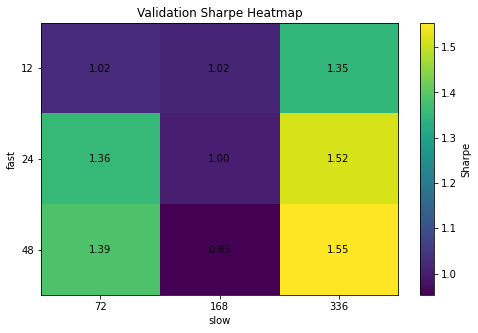

In [24]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 7.1 — Sharpe heatmap on VALIDATION
# ============================================

import matplotlib.pyplot as plt

# 1) 把长表变成矩阵
sharpe_matrix = scan_val_df.pivot(index="fast", columns="slow", values="sharpe")

# 2) 画图
plt.figure(figsize=(8, 5))
plt.imshow(sharpe_matrix, aspect="auto")

# 3) 坐标轴
plt.xticks(range(len(sharpe_matrix.columns)), sharpe_matrix.columns)
plt.yticks(range(len(sharpe_matrix.index)), sharpe_matrix.index)

plt.xlabel("slow")
plt.ylabel("fast")
plt.title("Validation Sharpe Heatmap")

# 4) 颜色条
plt.colorbar(label="Sharpe")

# 5) 在格子里写数值
for i in range(sharpe_matrix.shape[0]):
    for j in range(sharpe_matrix.shape[1]):
        value = sharpe_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.show()

In [25]:
print(val_df.index.min())
print(val_df.index.max())

2023-10-06 15:00:00+00:00
2024-12-17 19:00:00+00:00


这段时期其实是BTC的强势期，线性增长趋势强。

我们从热力图可以看出来slow72，336这两列比较强势，我们在组合多时期信号的时候，是不是可以选择sharpe强的这几段呢？

我们接下来尝试用这个6个时期的参数

在真正实际中，我们要做的事设计稳健信号，而不是找最佳参数

下面代码是筛选掉的参数在训练集跑的结果

In [26]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 8 — Filtered multi-horizon ensemble on train
# ============================================

pairs_filtered = [
    (12,72),(24,72),(48,72),
    (12,336),(24,336),(48,336)
]

data_train = train_df.copy().sort_index()

ret_train = data_train["close"].pct_change()
vol_train = ret_train.ewm(span=24*7, adjust=False).std()

signal_dict = {}

for fast, slow in pairs_filtered:

    ema_fast = data_train["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_train["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1
    signal = trend / vol_train

    signal_norm = signal / signal.rolling(500).std()

    signal_dict[f"{fast}_{slow}"] = signal_norm

signal_df = pd.DataFrame(signal_dict)

combo_signal = signal_df.mean(axis=1)

pos = np.tanh(combo_signal).shift(1).fillna(0)

turnover = pos.diff().abs().fillna(0)
cost = FEE_RATE * turnover

strategy_ret = pos * ret_train - cost

equity = (1 + strategy_ret.fillna(0)).cumprod()

peak = equity.cummax()
drawdown = equity / peak - 1

bt_filtered = pd.DataFrame({
    "strategy_ret": strategy_ret,
    "equity": equity,
    "drawdown": drawdown
})

metrics_filtered = metrics_from_bt(bt_filtered)

print("=== Filtered Multi-Horizon on TRAIN ===")
print(metrics_filtered)

=== Filtered Multi-Horizon on TRAIN ===
(0.48192562598724487, -0.5172570100246416, 0.518534773703309)


In [27]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 8.1 — Filtered multi-horizon on VALIDATION
# ============================================

pairs_filtered = [
    (12, 72), (24, 72), (48, 72),
    (12, 336), (24, 336), (48, 336)
]

# 1) 当前数据：validation集
data_val = val_df.copy().sort_index()

# 2) 收益率和波动率
ret_val = data_val["close"].pct_change()
vol_val = ret_val.ewm(span=24 * 7, adjust=False).std()

# 3) 构建 filtered signal
signal_dict_val_filtered = {}

for fast, slow in pairs_filtered:
    ema_fast = data_val["close"].ewm(span=fast, adjust=False).mean()
    ema_slow = data_val["close"].ewm(span=slow, adjust=False).mean()

    trend = ema_fast / ema_slow - 1.0
    signal = trend / vol_val

    # rolling normalization
    signal_norm = signal / signal.rolling(500).std()

    col_name = f"sig_{fast}_{slow}"
    signal_dict_val_filtered[col_name] = signal_norm

# 4) 合成 filtered ensemble signal
signal_df_val_filtered = pd.DataFrame(signal_dict_val_filtered, index=data_val.index)

combo_signal_val_filtered = signal_df_val_filtered.mean(axis=1)

# 5) 仓位映射
pos_val_filtered = np.tanh(combo_signal_val_filtered).shift(1).fillna(0)

# 6) 交易成本
turnover_val_filtered = pos_val_filtered.diff().abs().fillna(0)
cost_val_filtered = FEE_RATE * turnover_val_filtered

# 7) 策略收益
strategy_ret_val_filtered = pos_val_filtered * ret_val - cost_val_filtered

# 8) 资金曲线和回撤
equity_val_filtered = (1 + strategy_ret_val_filtered.fillna(0)).cumprod()
peak_val_filtered = equity_val_filtered.cummax()
drawdown_val_filtered = equity_val_filtered / peak_val_filtered - 1

# 9) 打包结果
bt_val_filtered = pd.DataFrame({
    "strategy_ret": strategy_ret_val_filtered,
    "equity": equity_val_filtered,
    "drawdown": drawdown_val_filtered
}, index=data_val.index)

# 10) 指标
metrics_val_filtered = metrics_from_bt(bt_val_filtered)

print("=== Filtered Multi-Horizon on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", metrics_val_filtered)

bt_val_filtered.tail()

=== Filtered Multi-Horizon on VALIDATION ===
Sharpe, MaxDD, TotalRet = (0.8701642555600759, -0.2800395946565851, 0.34875741475282873)


,strategy_ret,equity,drawdown
2024-12-17 15:00:00+00:00,-0.016425,1.348790,-0.067957
2024-12-17 16:00:00+00:00,0.005598,1.356341,-0.062739
2024-12-17 17:00:00+00:00,0.004014,1.361786,-0.058977
2024-12-17 18:00:00+00:00,-0.008862,1.349718,-0.067316
2024-12-17 19:00:00+00:00,-0.000712,1.348757,-0.067980


In [28]:
print("=== VALIDATION MODEL COMPARISON ===")
print("Single 48/336              :", single_val_metrics)
print("Multi EQ raw               :", combo_val_metrics)
print("Multi EQ normalized        :", metrics_norm_val)
print("Multi filtered normalized  :", metrics_val_filtered)

=== VALIDATION MODEL COMPARISON ===
Single 48/336              : (1.5534435936588291, -0.3819392869747842, 1.1400380947050541)
Multi EQ raw               : (1.0625796982506943, -0.34865330325332466, 0.593274487532842)
Multi EQ normalized        : (0.8264949056359038, -0.2751659277649675, 0.3236936784913329)
Multi filtered normalized  : (0.8701642555600759, -0.2800395946565851, 0.34875741475282873)


| Model                     | Sharpe   | MaxDD     | Return |
| ------------------------- | -------- | --------- | ------ |
| **Single 48/336**         | **1.55** | -0.38     | 1.12   |
| Multi EQ raw              | 1.05     | -0.35     | 0.58   |
| Multi EQ normalized       | 0.84     | **-0.27** | 0.33   |
| Multi filtered normalized | 0.87     | -0.28     | 0.35   |


在真实研究中我们一般保留三种模型：

1）基线模型baseline  例如这个single-horizon

2）结构模型 structured model 例如这个multi horizon ensemble

3）激进模型 aggressive model 例如这个 raw ensemble 捕捉更高alpha

接下里我们进行 final test，在测试集上对比他们
在test上跑ABC

In [29]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 9.1 — Run Model A / B / C on TEST
# ============================================

import numpy as np
import pandas as pd

ANNUAL = 24 * 365
FEE_RATE = 0.0004




# ----------------------------
# 2) Model A: Single Horizon
# ----------------------------
def backtest_single_horizon(df, ema_fast=48, ema_slow=336, fee_rate=0.0004):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0
    signal = trend / vol

    pos = np.tanh(signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt


# ----------------------------
# 3) Model B: Raw Multi-Horizon Equal Weight
# ----------------------------
def backtest_multi_raw(df, pairs, fee_rate=0.0004):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    signal_dict = {}

    for fast, slow in pairs:
        ema_fast = data["close"].ewm(span=fast, adjust=False).mean()
        ema_slow = data["close"].ewm(span=slow, adjust=False).mean()

        trend = ema_fast / ema_slow - 1.0
        signal = trend / vol

        signal_dict[f"sig_{fast}_{slow}"] = signal

    signal_df = pd.DataFrame(signal_dict, index=data.index)

    combo_signal = signal_df.mean(axis=1)
    pos = np.tanh(combo_signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt


# ----------------------------
# 4) Model C: Filtered Normalized Multi-Horizon
# ----------------------------
def backtest_multi_filtered_norm(df, pairs_filtered, fee_rate=0.0004, norm_window=500):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    signal_dict = {}

    for fast, slow in pairs_filtered:
        ema_fast = data["close"].ewm(span=fast, adjust=False).mean()
        ema_slow = data["close"].ewm(span=slow, adjust=False).mean()

        trend = ema_fast / ema_slow - 1.0
        signal = trend / vol

        signal_norm = signal / signal.rolling(norm_window).std()

        signal_dict[f"sig_{fast}_{slow}"] = signal_norm

    signal_df = pd.DataFrame(signal_dict, index=data.index)

    combo_signal = signal_df.mean(axis=1)
    pos = np.tanh(combo_signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt


# ----------------------------
# 5) 定义参数组
# ----------------------------
pairs_all = [
    (12, 72), (12, 168), (12, 336),
    (24, 72), (24, 168), (24, 336),
    (48, 72), (48, 168), (48, 336),
]

pairs_filtered = [
    (12, 72), (24, 72), (48, 72),
    (12, 336), (24, 336), (48, 336),
]


# ----------------------------
# 6) 在 TEST 上跑三个模型
# ----------------------------
bt_A_test = backtest_single_horizon(test_df, ema_fast=48, ema_slow=336, fee_rate=FEE_RATE)
bt_B_test = backtest_multi_raw(test_df, pairs=pairs_all, fee_rate=FEE_RATE)
bt_C_test = backtest_multi_filtered_norm(test_df, pairs_filtered=pairs_filtered, fee_rate=FEE_RATE, norm_window=500)

metrics_A_test = metrics_from_bt(bt_A_test)
metrics_B_test = metrics_from_bt(bt_B_test)
metrics_C_test = metrics_from_bt(bt_C_test)

print("=== TEST MODEL COMPARISON ===")
print("Model A | Single 48/336             :", metrics_A_test)
print("Model B | Multi EQ raw             :", metrics_B_test)
print("Model C | Multi filtered normalized:", metrics_C_test)

=== TEST MODEL COMPARISON ===
Model A | Single 48/336             : (0.49782740805767106, -0.30426978619031253, 0.15793000930344525)
Model B | Multi EQ raw             : (-0.21015607034106235, -0.4464763095286207, -0.19635937701830974)
Model C | Multi filtered normalized: (-0.5411293497440157, -0.36352628931808495, -0.23956196667627083)


画三条test资金曲线


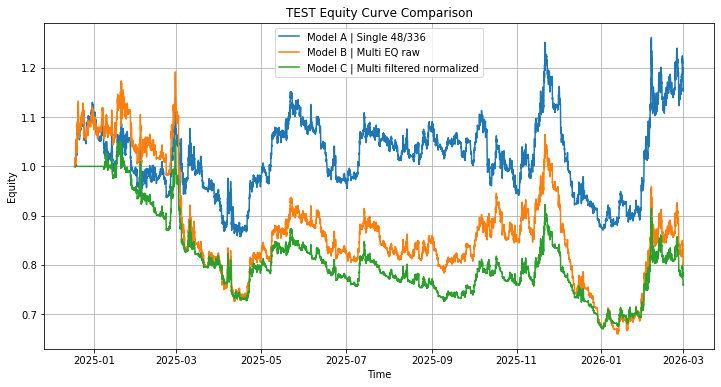

In [30]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 9.2 — Plot TEST equity curves
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(bt_A_test.index, bt_A_test["equity"], label="Model A | Single 48/336")
plt.plot(bt_B_test.index, bt_B_test["equity"], label="Model B | Multi EQ raw")
plt.plot(bt_C_test.index, bt_C_test["equity"], label="Model C | Multi filtered normalized")

plt.title("TEST Equity Curve Comparison")
plt.xlabel("Time")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)

plt.show()

test回撤曲线

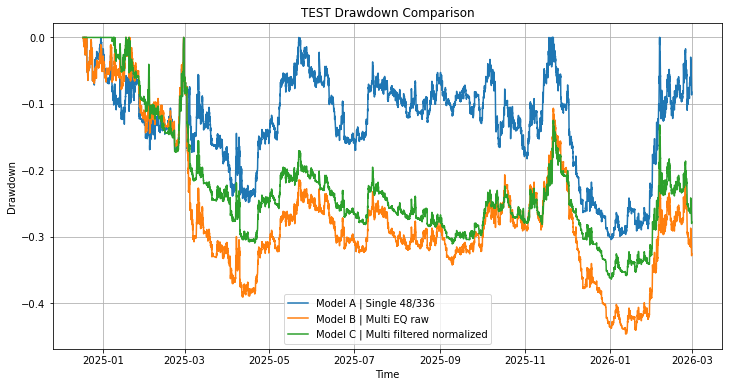

In [31]:
# ============================================
# Phase 3 — Strategy Research
# Task 3.2 — Multi-horizon Momentum
# Step 9.3 — Plot TEST drawdown curves
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(bt_A_test.index, bt_A_test["drawdown"], label="Model A | Single 48/336")
plt.plot(bt_B_test.index, bt_B_test["drawdown"], label="Model B | Multi EQ raw")
plt.plot(bt_C_test.index, bt_C_test["drawdown"], label="Model C | Multi filtered normalized")

plt.title("TEST Drawdown Comparison")
plt.xlabel("Time")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.show()

我们这波还没有加入风险控制部分，再一个合成的多期信号，只是对每个时间段信号取了普通平均，我们可以根据sharpe进行加权处理。

然后取看收益曲线，发现其实趋势策略，它仅仅是靠那几段大上升趋势来赚钱的，其他地方是主要是抵抗波动风险，也就是震荡市场被反复止损。因为交易成本+噪音会把资金磨掉。

所以趋势策略优化通常是，减少振荡期的反复交易：

1）波动率过滤

只在 high volatility regime 交易

2）趋势强度过滤 |signal| > threshold

弱信号不交易，减少交易成本

3）volatility targeting
target 20% annual vol  避免仓位过大

接下里对这些模型接入risk控制部分：\
price                           signal

↓

trend signal                    direction = tanh(signal)    

↓           

signal mapping                  size = target_vol / realized_vol

↓

volatility targeting            position = direction × size

↓

position

↓

PnL